# Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch1 2026-2027 — Major Project**

## 1. Introduction

Agricultural performance is influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. This notebook analyzes a seasonal agriculture dataset to investigate how yield, profit, water efficiency, and pest risk vary across the Kharif, Rabi, and Zaid seasons, and to identify meaningful patterns that can support evidence-based agricultural planning.

## 2. Dataset

The dataset (seasonal_agriculture_performance_dataset.csv) contains 4,000 farm-level records across multiple Indian states, crops, and irrigation methods, with columns covering farming practices, environmental conditions, and outcomes.

In [5]:
import pandas as pd

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


	## 3. Data Exploration

In [6]:
df.shape            # rows, columns

(4000, 28)

In [7]:
df.info()           # data types + non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.describe()       # mean, min, max, std for numeric columns

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
df.isnull().sum()   # check missing values

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [10]:
df.duplicated().sum()   # check duplicate rows

np.int64(0)

In [11]:
df['Season'].unique()
df['Crop'].unique()
df['State'].unique()
df['Irrigation_Method'].unique()

array(['Drip', 'Flood', 'Rainfed', 'Sprinkler'], dtype=object)

## 4. Data Cleaning

Missing numeric values (Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha) are filled with the column median. No duplicate rows were found.

In [12]:
# Fill missing numeric values with median
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

# Standardize text columns
df['Season'] = df['Season'].str.strip().str.title()
df['Crop'] = df['Crop'].str.strip().str.title()
df['State'] = df['State'].str.strip().str.title()

# Confirm no missing values remain
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.to_csv('cleaned_seasonal_agriculture_data.csv', index=False)

## 5. Analytical Questions

## Analytical Questions

1. How does average Yield and Profit differ across seasons (Kharif, Rabi, Zaid)?
2. Which crops perform best (highest yield/profit) in which season?
3. How do Rainfall and Temperature correlate with Yield?
4. Does Irrigation Method affect Water Efficiency differently by season?
5. Are there state-wise differences in performance within the same season?
6. Does Disease/Pest Risk vary by season, and does it affect profit?
7. What's the relationship between Fertilizer usage and Yield?

## 6. Analysis

Season-wise, crop-wise, state-wise, and irrigation-wise summaries to answer the analytical questions above.

In [14]:
season_summary = df.groupby('Season')[['Yield_Tonnes_Ha','Profit_INR',
    'Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']].mean().round(2)
print(season_summary)

        Yield_Tonnes_Ha  Profit_INR  Water_Efficiency_t_per_1000m3  \
Season                                                               
Kharif             5.63   178914.65                           5.89   
Rabi               5.04    87689.47                           5.19   
Zaid               4.64   -24804.82                           4.41   

        Disease_Pest_Risk_pct  
Season                         
Kharif                  54.47  
Rabi                    40.48  
Zaid                    38.22  


In [15]:
# Season + Crop: average yield
crop_season = df.groupby(['Season','Crop'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
print(crop_season)

Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif    1.73    1.37       1.48   2.97    1.04  2.70      53.46   2.25
Rabi      1.47    1.20       1.23   2.60    0.88  2.32      43.29   2.06
Zaid      1.20    0.96       1.04   2.29    0.67  1.90      38.42   1.75


In [16]:
# Season + State: average profit
state_season = df.groupby(['Season','State'])['Profit_INR'].mean().unstack().round(2)
print(state_season)

State   Andhra Pradesh    Gujarat  Karnataka  Madhya Pradesh  Maharashtra  \
Season                                                                      
Kharif       169315.52  217051.33  201226.21       134242.40    168801.05   
Rabi          26315.71   82846.20   70952.61        61576.26    159581.50   
Zaid         -84084.87 -106929.61   23310.91          209.70    -40597.60   

State      Punjab  Tamil Nadu  Telangana  
Season                                    
Kharif  133779.10   211303.96  199668.38  
Rabi    169294.52    70456.86   62824.60  
Zaid     62109.69   -15175.20  -34620.78  


In [17]:
# Season + Irrigation Method: water efficiency
irrigation_season = df.groupby(['Season','Irrigation_Method'])['Water_Efficiency_t_per_1000m3'].mean().unstack().round(2)
print(irrigation_season)

Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             6.80   3.64     8.85       4.62
Rabi               6.05   3.48     6.87       4.64
Zaid               5.30   2.73     5.48       4.86


## 7. Visualizations

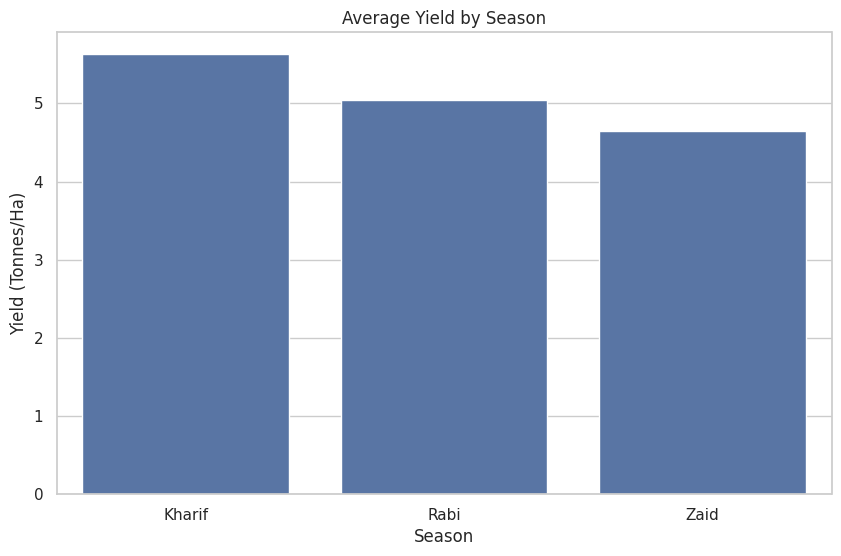

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Chart 1: Average Yield by Season
plt.figure()
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', estimator='mean', errorbar=None)
plt.title('Average Yield by Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.savefig('chart1_yield_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

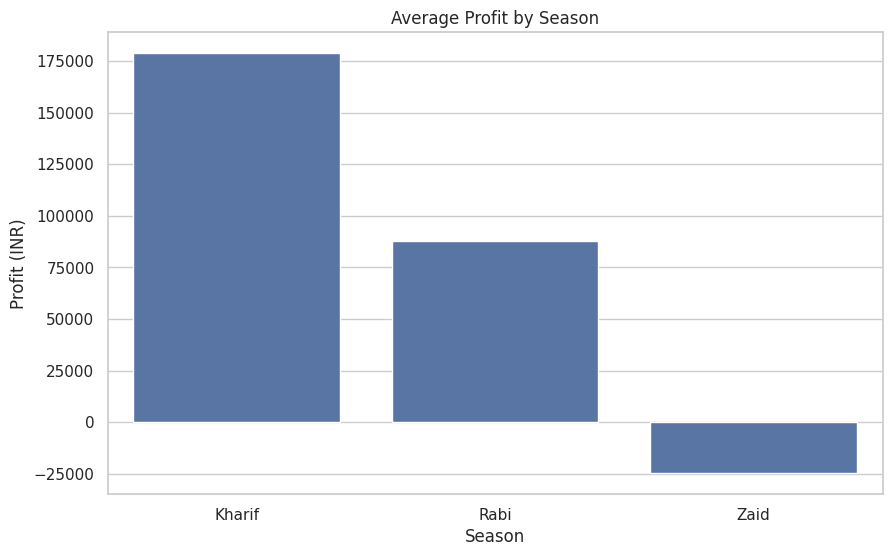

In [19]:
# Chart 2: Average Profit by Season
plt.figure()
sns.barplot(data=df, x='Season', y='Profit_INR', estimator='mean', errorbar=None)
plt.title('Average Profit by Season')
plt.ylabel('Profit (INR)')
plt.savefig('chart2_profit_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

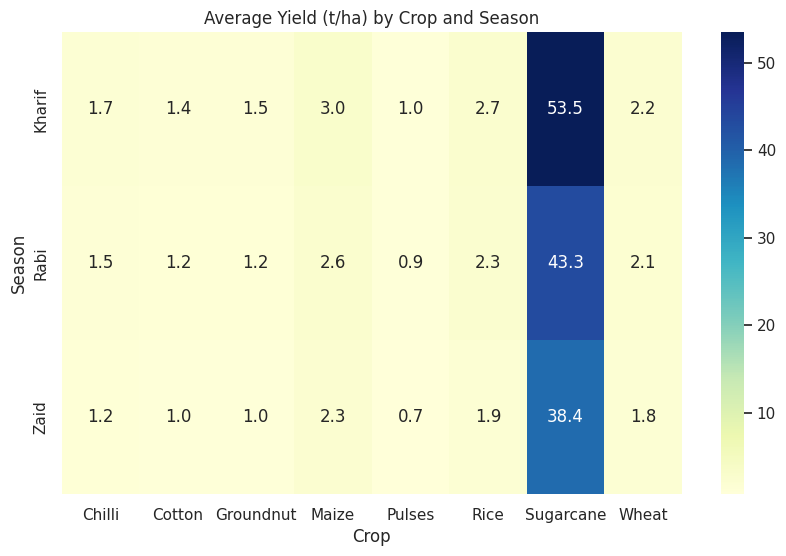

In [20]:
# Chart 3: Crop performance by season (heatmap)
plt.figure(figsize=(10,6))
sns.heatmap(crop_season, annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Average Yield (t/ha) by Crop and Season')
plt.savefig('chart3_crop_season_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

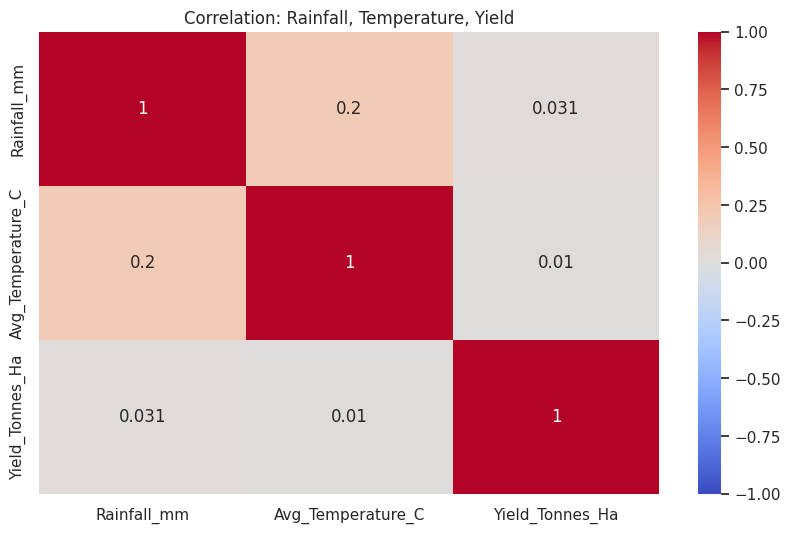

In [21]:
# Chart 4: Rainfall & Temperature correlation with Yield
plt.figure(figsize=(10,6))
corr = df[['Rainfall_mm','Avg_Temperature_C','Yield_Tonnes_Ha']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Rainfall, Temperature, Yield')
plt.savefig('chart4_rainfall_temp_yield_corr.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

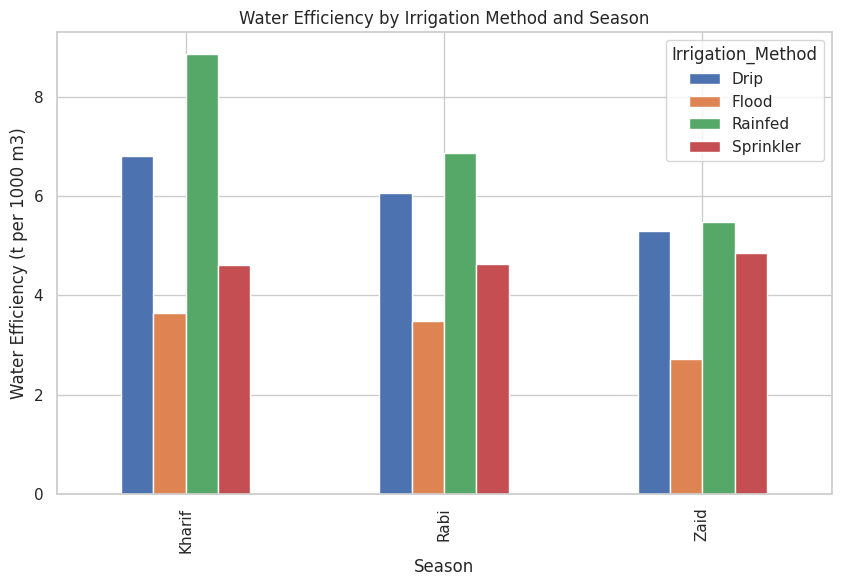

In [22]:
# Chart 5: Irrigation Method vs Water Efficiency by Season
plt.figure()
irrigation_season.plot(kind='bar')
plt.title('Water Efficiency by Irrigation Method and Season')
plt.ylabel('Water Efficiency (t per 1000 m3)')
plt.savefig('chart5_irrigation_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

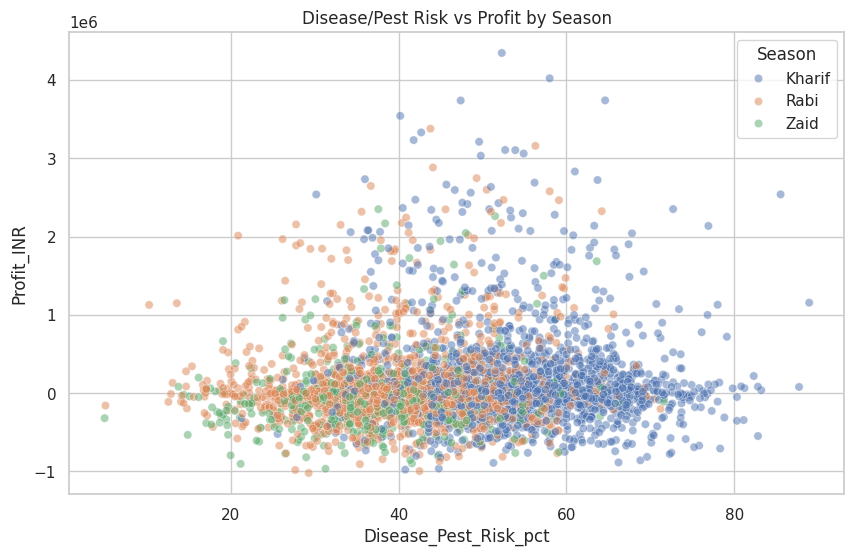

In [23]:
# Chart 6: Disease/Pest Risk by Season vs Profit
plt.figure()
sns.scatterplot(data=df, x='Disease_Pest_Risk_pct', y='Profit_INR', hue='Season', alpha=0.5)
plt.title('Disease/Pest Risk vs Profit by Season')
plt.savefig('chart6_pest_risk_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()

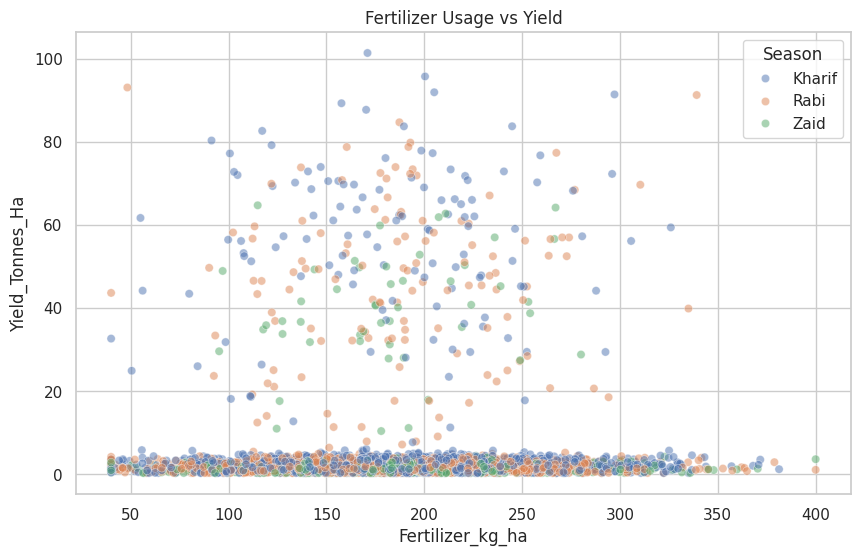

In [24]:
# Chart 7: Fertilizer usage vs Yield
plt.figure()
sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5)
plt.title('Fertilizer Usage vs Yield')
plt.savefig('chart7_fertilizer_vs_yield.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

1. Kharif is the most profitable and highest-yielding season; Zaid runs at a loss on average.
2. Sugarcane vastly outperforms other crops in yield across all seasons.
3. Rainfall and temperature show a very weak correlation with yield in this dataset (0.03 and 0.01 respectively); this suggests yield here is not strongly explained by these two variables alone, though we did not test other factors that might explain more of the variation.
4. Rainfed farming shows the highest water efficiency, followed by Drip; Flood is the least efficient.
5. Disease/Pest risk does not show a consistent relationship with profit.
6. Fertilizer usage shows a near-zero correlation with yield in this dataset (~0.001); this is an unexpected pattern that would benefit from further investigation.
## 9. Recommendations

1. Prioritize Kharif-season planning and resource allocation, given its consistently higher yield and profit.
2. Investigate the causes of the Zaid-season loss (e.g. crop mix, input costs) before the next planning cycle.
3. Encourage rainfed and drip irrigation over flood irrigation, based on their higher water efficiency.
4. Review fertilizer application practices, since higher usage is not associated with higher yield in this dataset.
5. Study high-yield crops such as Sugarcane further to assess their scalability in other suitable regions.
## 10. Conclusion

This analysis shows that agricultural performance in this dataset varies meaningfully across seasons, with Kharif consistently outperforming Rabi and Zaid on both yield and profit. Crop choice and irrigation method appear to matter more than the two weather variables examined here (rainfall and temperature), and fertilizer usage does not show a clear relationship with yield. These findings support the recommendations above and point to specific areas — seasonal input costs, fertilizer practices, and crop scalability — that would benefit from deeper investigation.